<div style="display: flex; align-items: center; justify-content: center; flex-wrap: wrap;">
    <div style="flex: 1; max-width: 400px; display: flex; justify-content: center;">
        <img src="https://magic.novaims.unl.pt/media/1tdf2arr/ims25_horizontal__positivo_rgb.svg" style="max-width: 70%; height: auto; margin-top: 50px; margin-bottom: 50px; margin-left: 6rem;">
    </div>
    <div style="flex: 2; text-align: center; margin-top: 20px; margin-left: 6rem;">
        <div style="font-size: 28px; font-weight: bold; line-height: 1.2;">
            <span style="color: #FFCD41;">Thesis Project |</span> <span style="color: #F58228;">LISBOA Evaluation Results Analysis</span>
        </div>
        <div style="font-size: 17px; font-weight: bold; margin-top: 10px;">2025 - 2026</div>
        <div style="font-size: 17px; font-weight: bold;">Master in Data Science and Advanced Analytics</div>
        <div style="margin-top: 20px;"><div>André Filipe Gomes Silvestre, 20240502</div></div>
    </div>
</div>

<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: linear-gradient(to right, #F58228, #FFCD41); padding: 15px; color: white; border-radius: 300px; text-align: center;">
    <center><h1 style="margin-left: 100px; margin-top: 10px; margin-bottom: 4px; color: white; font-size: 32px; font-family: 'Avenir Next LT Pro', sans-serif;"><b>Benchmark and Ablation Analysis</b></h1></center>
</div>

<br><br>

## **Notebook overview**

This notebook analyses the persisted evaluation artefacts under `eval/results/` and turns them into thesis-ready tables and figures. As of 2026-04, the shared evaluation corpus contains 72 entries across 6 domains, while each saved benchmark or ablation artefact can use a narrower subset depending on the runner and its filters.

### **What this notebook does**

1. Maps the full shared evaluation corpus and the smaller subsets actually used by each artefact.
2. Compares isolated worker-agent benchmark results across the response models stored in the JSON outputs.
3. Reframes the ablation around quality lift, operational trade-offs, and grounded-system evidence.
4. Summarises strict live coverage, provider consistency, and optional calibration without overloading the main narrative.
5. Reads the stored metadata dynamically so dataset-path overrides and custom `output-prefix` runs remain analysable without rewriting the notebook.

## **Evaluation scope and reading guide**

This repository uses several complementary evaluation layers, and each one answers a different methodological question:

- **Shared corpus**: the full `evaluation_groundtruth_queries.json` file defines the overall evaluation scope, domain balance, expected tools, and expected facts.
- **Benchmark**: evaluates isolated worker agents, not the full LISBOA orchestration pipeline.
- **Ablation**: compares a zero-shot baseline against the full LISBOA system on the same persisted query subset.
- **Coverage**: checks whether the strict live prompt manifest exercises the exported tool registry.
- **Provider consistency**: checks whether different providers preserve the same response contract and presentation style.
- **Calibration**: optionally compares human scores with judge scores when a calibration artefact is available.

### **Interpretation notes**

- Counts shown for the full corpus are not the same as the counts used in each saved artefact.
- The default ablation runner focuses on the grounded pipeline domains and excludes `greeting` plus `out_of_scope`, because those are direct SupervisorAgent shortcuts rather than grounded worker-agent flows.
- Benchmark plots treat **tool F1** as a grounded quality signal for isolated worker agents.
- Ablation plots do **not** treat zero-shot and LISBOA as symmetric on tool use, because zero-shot has no tool grounding by design.
- When the sample size is small, this notebook prefers annotated grouped bars, compact tables, and trade-off plots over boxplots.

In [ ]:
# ==========================================================================
# Core setup
# ==========================================================================
# pip install pandas numpy matplotlib seaborn

import json
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import font_manager
from matplotlib.axes import Axes
from matplotlib.figure import Figure

%matplotlib inline


def resolve_project_root() -> Path:
    """Resolve the repository root even when the notebook is opened from eval/."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "config.py").exists() and (candidate / "eval" / "results").exists():
            return candidate
    return Path.cwd()


def pick_plot_font() -> str:
    """Pick the closest available font to the thesis notebook style."""
    preferred_fonts = ["Avenir Next LT Pro", "Avenir Next", "Arial", "DejaVu Sans"]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            return font_name
    return "DejaVu Sans"


PROJECT_ROOT = resolve_project_root()
EVAL_DIR = PROJECT_ROOT / "eval"
EVAL_RESULTS_DIR = EVAL_DIR / "results"
CORPUS_PATH = EVAL_DIR / "evaluation_groundtruth_queries.json"
DEMO_CORPUS_PATH = EVAL_DIR / "evaluation_groundtruth_queries_demo.json"
FIGURES_DIR = EVAL_RESULTS_DIR / "figures"
EXPORT_DPI = 300
EXPORT_MAIN_FIGURES = True
EXPORT_FLAT_TABLES = False
MAIN_FIGURE_EXPORTS = {
    "benchmark_quality_grounding",
    "benchmark_operational_profile",
    "ablation_quality_lift",
    "ablation_tradeoffs",
}
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PLOT_FONT = pick_plot_font()

PRIMARY_RED = "#d9482a"
SECONDARY_ORANGE = "#f2a65a"
ACCENT_YELLOW = "#f6da00"
NEUTRAL_GREY = "#8b96a3"
LIGHT_GREY = "#d9dfe6"
DARK_GREY = "#2f2f2f"
SOFT_BLUE = "#6b93c6"
SOFT_GREEN = "#6fa36b"
SOFT_SILVER = "#c9d2dd"

PROJECT_PALETTE = [PRIMARY_RED, SECONDARY_ORANGE, SOFT_BLUE, SOFT_GREEN, ACCENT_YELLOW]

sns.set_theme(context="notebook", style="whitegrid", font=PLOT_FONT, font_scale=1.0)
sns.set_palette(PROJECT_PALETTE)
plt.rcParams["figure.figsize"] = (15, 7)
plt.rcParams["figure.dpi"] = EXPORT_DPI
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11.5
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 10.0
plt.rcParams["ytick.labelsize"] = 10.0
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["legend.title_fontsize"] = 10
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [PLOT_FONT, "Arial", "DejaVu Sans"]
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["axes.edgecolor"] = DARK_GREY
plt.rcParams["text.color"] = DARK_GREY
plt.rcParams["axes.labelcolor"] = DARK_GREY
plt.rcParams["xtick.color"] = DARK_GREY
plt.rcParams["ytick.color"] = DARK_GREY
plt.rcParams["grid.color"] = LIGHT_GREY
plt.rcParams["grid.alpha"] = 0.55
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Corpus path: {CORPUS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Demo corpus path: {DEMO_CORPUS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Figures directory: {FIGURES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Automatic figure export: {EXPORT_MAIN_FIGURES}")
print(f"Automatic flat-table export: {EXPORT_FLAT_TABLES}")
print(f"Plot font: {PLOT_FONT}")

Project root: c:\Users\andre\OneDrive - NOVAIMS\[MDSAA-DS]_Thesis\Thesis2025-26_AFGS
Corpus path: eval\evaluation_groundtruth_queries.json
Demo corpus path: eval\evaluation_groundtruth_queries_demo.json
Figures directory: eval\results\figures
Automatic figure export: True
Automatic flat-table export: False
Plot font: Avenir Next LT Pro


In [2]:
# ==========================================================================
# Formatting and plotting helpers
# ==========================================================================
DOMAIN_LABELS = {
    "weather": "Weather",
    "transport": "Transport",
    "researcher": "Researcher",
    "multi_agent": "Multi-agent",
    "greeting": "Greeting",
    "out_of_scope": "Out of scope",
}
BENCHMARK_DOMAIN_ORDER = ["Weather", "Transport", "Researcher"]
ABLATION_DOMAIN_ORDER = ["Greeting", "Weather", "Transport", "Researcher", "Multi-agent", "Out of scope"]
ARM_LABELS = {"zero_shot": "Zero-shot", "lisboa": "LISBOA"}
ARM_PALETTE = {"Zero-shot": SOFT_SILVER, "LISBOA": PRIMARY_RED}


def format_model_label(model_name: str | None) -> str:
    """Format model labels for notebook display without provider prefixes."""
    if model_name is None:
        return "N/A"

    label = str(model_name).strip()
    special_labels = {
        "Multi-Agent (gpt-5-mini)": "LISBOA Multi-Agent",
        "multi_agent": "LISBOA Multi-Agent",
        "zero_shot": "Zero-shot",
        "lisboa": "LISBOA",
    }
    if label in special_labels:
        return special_labels[label]

    if "::" in label:
        label = label.split("::", 1)[1]

    if label.lower().startswith("multi-agent"):
        inner = re.search(r"\((.+)\)", label)
        if inner:
            return f"LISBOA Multi-Agent ({format_model_label(inner.group(1))})"
        return "LISBOA Multi-Agent"

    if label.lower() == "qwen/qwen3.5-9b":
        return "Qwen 3.5 9B"

    if label.lower().startswith("kimi-k2.5"):
        suffix = label[len("kimi-k2.5"):].strip(" -_")
        return "Kimi K2.5" if not suffix else f"Kimi K2.5 {suffix.replace('-', ' ').title()}"

    gpt_match = re.fullmatch(r"gpt-(\d+(?:\.\d+)?)(?:-(.+))?", label.lower())
    if gpt_match:
        version, variant = gpt_match.groups()
        if variant:
            formatted_variant = " ".join(
                part.upper() if len(part) <= 2 else part.capitalize()
                for part in variant.split("-")
            )
            return f"GPT-{version} {formatted_variant}"
        return f"GPT-{version}"

    return label.replace("_", " ").replace("-", " ").title()


def format_domain_label(domain_name: str | None) -> str:
    """Format evaluation domains for notebook display."""
    if domain_name is None:
        return "Unknown"
    return DOMAIN_LABELS.get(str(domain_name), str(domain_name).replace("_", " ").title())


def format_arm_label(arm_name: str | None) -> str:
    """Format ablation arm names for notebook display."""
    if arm_name is None:
        return "Unknown"
    return ARM_LABELS.get(str(arm_name), str(arm_name).replace("_", " ").title())


def format_response_models_for_inventory(value: Any) -> str:
    """Format response model inventories for display without provider prefixes."""
    if isinstance(value, dict):
        return " | ".join(
            f"{format_arm_label(key)}: {format_model_label(model)}"
            for key, model in value.items()
        )
    if isinstance(value, (list, tuple, set)):
        return ", ".join(format_model_label(model) for model in value)
    if value is None:
        return "N/A"
    return format_model_label(str(value))


def build_palette(labels: list[str]) -> dict[str, str]:
    """Map labels to the project palette in a stable order."""
    return {
        label: PROJECT_PALETTE[index % len(PROJECT_PALETTE)]
        for index, label in enumerate(labels)
    }


def save_figure(name: str, fig: Figure | None = None) -> Path | None:
    """Export only the selected thesis-ready SVG figures."""
    if not EXPORT_MAIN_FIGURES or name not in MAIN_FIGURE_EXPORTS:
        return None

    fig = fig or plt.gcf()
    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        ax.set_facecolor("white")

    for ext in ("png", "pdf"):
        legacy_path = FIGURES_DIR / f"{name}.{ext}"
        if legacy_path.exists():
            legacy_path.unlink()

    svg_path = FIGURES_DIR / f"{name}.svg"
    fig.savefig(svg_path, format="svg", bbox_inches="tight", facecolor="white")
    print(f"Exported: {svg_path.relative_to(PROJECT_ROOT)}")
    return svg_path


def style_axis(
    ax: Axes,
    title: str,
    xlabel: str,
    ylabel: str,
    *,
    rotate_xticks: int = 0,
    y_limits: tuple[float, float] | None = None,
    show_y_grid: bool = True,
) -> None:
    """Apply a thesis-ready style to an axis."""
    ax.set_facecolor("white")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel, fontsize=11.5, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11.5, fontweight="bold")
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    ax.tick_params(axis="x", rotation=rotate_xticks)
    if show_y_grid:
        ax.grid(True, axis="y", linestyle="--", alpha=0.55, color=LIGHT_GREY)
    else:
        ax.grid(False, axis="y")
    sns.despine(ax=ax, left=True, bottom=False)


def style_legend(ax: Axes, title: str, bbox_to_anchor: tuple[float, float] = (1.02, 1.0)) -> None:
    """Move and style a legend consistently across plots."""
    if ax.legend_ is None:
        return
    sns.move_legend(ax, "upper left", bbox_to_anchor=bbox_to_anchor, title=title, frameon=True)
    if ax.legend_ is None:
        return
    ax.legend_.get_title().set_fontweight("bold")
    ax.legend_.get_frame().set_edgecolor("#d0d0d0")
    ax.legend_.get_frame().set_linewidth(0.8)
    ax.legend_.get_frame().set_alpha(0.98)


def format_demo_runner(domain_name: str) -> str:
    """Return the most appropriate runner for a demo query domain."""
    if domain_name in {"weather", "transport", "researcher"}:
        return "Benchmark and ablation"
    return "Ablation only"

In [3]:
# ==========================================================================
# Artefact and flattening helpers
# ==========================================================================

def find_latest_artifact(subdir: str, prefix: str, required: bool = True) -> Path | None:
    """Return the latest timestamped JSON artefact in a results subdirectory."""
    artifact_dir = EVAL_RESULTS_DIR / subdir
    if not artifact_dir.exists():
        if required:
            raise FileNotFoundError(f"Missing artefact directory: {artifact_dir}")
        return None

    matches = sorted(artifact_dir.glob(f"{prefix}_*.json"))
    if not matches:
        if required:
            raise FileNotFoundError(f"No artefacts found in {artifact_dir} matching {prefix}_*.json")
        return None
    return matches[-1]



def load_json(path: Path | None) -> dict[str, Any] | None:
    """Load a JSON payload if the path exists."""
    if path is None:
        return None
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)



def load_required_json(path: Path) -> dict[str, Any]:
    """Load a required JSON payload and fail loudly when absent."""
    payload = load_json(path)
    if payload is None:
        raise ValueError(f"Expected JSON payload at {path}, but found None.")
    return payload



def artefact_timestamp(payload: dict[str, Any] | None) -> str:
    """Extract the most relevant timestamp from an artefact payload."""
    if not payload:
        return "n/a"

    timestamp_candidates = [
        payload.get("generated_at"),
        (payload.get("benchmark_metadata") or {}).get("timestamp"),
        (payload.get("ablation_metadata") or {}).get("timestamp"),
        (payload.get("coverage_metadata") or {}).get("timestamp"),
        (payload.get("calibration_metadata") or {}).get("timestamp"),
    ]
    for value in timestamp_candidates:
        if value:
            return str(value)
    return "n/a"



def _extract_token_triplet(payload: dict[str, Any] | None) -> tuple[int, int, int]:
    payload = payload or {}
    tokens = payload.get("tokens", {}) or {}
    return (
        int(tokens.get("input_tokens", 0) or 0),
        int(tokens.get("output_tokens", 0) or 0),
        int(tokens.get("total_tokens", 0) or 0),
    )



def _extract_cost_triplet(payload: dict[str, Any] | None) -> tuple[float, float, float]:
    payload = payload or {}
    return (
        float(payload.get("input_cost_usd", 0.0) or 0.0),
        float(payload.get("output_cost_usd", 0.0) or 0.0),
        float(payload.get("total_cost_usd", 0.0) or 0.0),
    )



def flatten_benchmark_results(payload: dict[str, Any]) -> pd.DataFrame:
    """Flatten benchmark records into an analysis-ready dataframe."""
    rows = []
    for record in payload.get("benchmark_results", []):
        scores = record.get("scores") or {}
        heuristics = record.get("heuristics") or {}
        tool_metrics = record.get("tool_metrics") or {}
        response_usage = record.get("response_usage") or {}
        evaluation_usage = record.get("evaluation_usage") or {}
        combined_usage = record.get("combined_usage") or {}
        response_cost = record.get("response_cost_usd") or {}
        evaluation_cost = record.get("evaluation_cost_usd") or {}
        combined_cost = record.get("combined_cost_usd") or {}

        response_input_tokens, response_output_tokens, response_total_tokens = _extract_token_triplet(response_usage)
        evaluation_input_tokens, evaluation_output_tokens, evaluation_total_tokens = _extract_token_triplet(evaluation_usage)
        combined_input_tokens, combined_output_tokens, combined_total_tokens = _extract_token_triplet(combined_usage)
        response_input_cost, response_output_cost, response_total_cost = _extract_cost_triplet(response_cost)
        evaluation_input_cost, evaluation_output_cost, evaluation_total_cost = _extract_cost_triplet(evaluation_cost)
        combined_input_cost, combined_output_cost, combined_total_cost = _extract_cost_triplet(combined_cost)

        rows.append(
            {
                "id": record.get("id"),
                "domain": record.get("domain"),
                "query": record.get("query"),
                "response_model": record.get("response_model"),
                "evaluation_model": record.get("evaluation_model"),
                "latency_s": record.get("latency_s"),
                "composite_score": scores.get("composite_score"),
                "factual_accuracy": scores.get("factual_accuracy"),
                "tool_usage": scores.get("tool_usage"),
                "completeness": scores.get("completeness"),
                "relevance": scores.get("relevance"),
                "response_quality": scores.get("response_quality"),
                "tool_precision": tool_metrics.get("tool_precision"),
                "tool_recall": tool_metrics.get("tool_recall"),
                "tool_f1": tool_metrics.get("tool_f1"),
                "heuristics_pass": heuristics.get("overall_pass"),
                "sla_met": record.get("sla_met"),
                "error_type": record.get("error_type"),
                "response_call_count": response_usage.get("call_count", 0),
                "evaluation_call_count": evaluation_usage.get("call_count", 0),
                "combined_call_count": combined_usage.get("call_count", 0),
                "response_input_tokens": response_input_tokens,
                "response_output_tokens": response_output_tokens,
                "response_total_tokens": response_total_tokens,
                "evaluation_input_tokens": evaluation_input_tokens,
                "evaluation_output_tokens": evaluation_output_tokens,
                "evaluation_total_tokens": evaluation_total_tokens,
                "combined_input_tokens": combined_input_tokens,
                "combined_output_tokens": combined_output_tokens,
                "combined_total_tokens": combined_total_tokens,
                "response_input_cost_usd": response_input_cost,
                "response_output_cost_usd": response_output_cost,
                "response_total_cost_usd": response_total_cost,
                "evaluation_input_cost_usd": evaluation_input_cost,
                "evaluation_output_cost_usd": evaluation_output_cost,
                "evaluation_total_cost_usd": evaluation_total_cost,
                "combined_input_cost_usd": combined_input_cost,
                "combined_output_cost_usd": combined_output_cost,
                "combined_total_cost_usd": combined_total_cost,
            }
        )
    return pd.DataFrame(rows)



def flatten_ablation_results(payload: dict[str, Any]) -> pd.DataFrame:
    """Flatten ablation records into an analysis-ready dataframe."""
    rows = []
    primary_profile = (
        payload.get("summary", {}).get("primary_comparison_profile")
        or payload.get("ablation_metadata", {}).get("primary_comparison_profile")
    )

    for record in payload.get("ablation_results", []):
        metrics_root = record.get("metrics")
        if metrics_root is None and primary_profile:
            metrics_root = (record.get("comparisons", {}).get(primary_profile) or {}).get("metrics")
        metrics_root = metrics_root or {}

        for arm in ("zero_shot", "lisboa"):
            metrics = metrics_root.get(arm, {})
            scores = metrics.get("scores") or {}
            heuristics = metrics.get("heuristics") or {}
            tool_metrics = metrics.get("tool_metrics") or {}
            response_usage = metrics.get("response_usage") or {}
            evaluation_usage = metrics.get("evaluation_usage") or {}
            combined_usage = metrics.get("combined_usage") or {}
            response_cost = metrics.get("response_cost_usd") or {}
            evaluation_cost = metrics.get("evaluation_cost_usd") or {}
            combined_cost = metrics.get("combined_cost_usd") or {}

            response_input_tokens, response_output_tokens, response_total_tokens = _extract_token_triplet(response_usage)
            evaluation_input_tokens, evaluation_output_tokens, evaluation_total_tokens = _extract_token_triplet(evaluation_usage)
            combined_input_tokens, combined_output_tokens, combined_total_tokens = _extract_token_triplet(combined_usage)
            response_input_cost, response_output_cost, response_total_cost = _extract_cost_triplet(response_cost)
            evaluation_input_cost, evaluation_output_cost, evaluation_total_cost = _extract_cost_triplet(evaluation_cost)
            combined_input_cost, combined_output_cost, combined_total_cost = _extract_cost_triplet(combined_cost)

            rows.append(
                {
                    "id": record.get("id"),
                    "domain": record.get("domain"),
                    "query": record.get("query"),
                    "arm": arm,
                    "response_model": metrics.get("response_model"),
                    "evaluation_model": metrics.get("evaluation_model"),
                    "latency_s": metrics.get("latency"),
                    "composite_score": scores.get("composite_score"),
                    "factual_accuracy": scores.get("factual_accuracy"),
                    "tool_usage": scores.get("tool_usage"),
                    "completeness": scores.get("completeness"),
                    "relevance": scores.get("relevance"),
                    "response_quality": scores.get("response_quality"),
                    "tool_precision": tool_metrics.get("tool_precision"),
                    "tool_recall": tool_metrics.get("tool_recall"),
                    "tool_f1": tool_metrics.get("tool_f1"),
                    "heuristics_pass": heuristics.get("overall_pass"),
                    "error_type": metrics.get("error_type"),
                    "response_call_count": response_usage.get("call_count", 0),
                    "evaluation_call_count": evaluation_usage.get("call_count", 0),
                    "combined_call_count": combined_usage.get("call_count", 0),
                    "response_input_tokens": response_input_tokens,
                    "response_output_tokens": response_output_tokens,
                    "response_total_tokens": response_total_tokens,
                    "evaluation_input_tokens": evaluation_input_tokens,
                    "evaluation_output_tokens": evaluation_output_tokens,
                    "evaluation_total_tokens": evaluation_total_tokens,
                    "combined_input_tokens": combined_input_tokens,
                    "combined_output_tokens": combined_output_tokens,
                    "combined_total_tokens": combined_total_tokens,
                    "response_input_cost_usd": response_input_cost,
                    "response_output_cost_usd": response_output_cost,
                    "response_total_cost_usd": response_total_cost,
                    "evaluation_input_cost_usd": evaluation_input_cost,
                    "evaluation_output_cost_usd": evaluation_output_cost,
                    "evaluation_total_cost_usd": evaluation_total_cost,
                    "combined_input_cost_usd": combined_input_cost,
                    "combined_output_cost_usd": combined_output_cost,
                    "combined_total_cost_usd": combined_total_cost,
                }
            )
    return pd.DataFrame(rows)



def flatten_consistency_results(payload: dict[str, Any] | None) -> pd.DataFrame:
    """Flatten provider-consistency records for compact analysis tables."""
    if not payload:
        return pd.DataFrame()

    rows = []
    for record in payload.get("records", []):
        comparison = record.get("comparison") or {}
        for result in record.get("results", []):
            heuristics = result.get("heuristics") or {}
            rows.append(
                {
                    "id": record.get("id"),
                    "category": record.get("category"),
                    "provider": result.get("provider"),
                    "model_name": result.get("model_name"),
                    "latency_s": result.get("latency_s"),
                    "overall_pass": heuristics.get("overall_pass"),
                    "consistent": comparison.get("consistent"),
                }
            )
    return pd.DataFrame(rows)



def build_artifact_inventory(
    benchmark_path: Path,
    benchmark_payload: dict[str, Any],
    ablation_path: Path,
    ablation_payload: dict[str, Any],
    coverage_path: Path | None = None,
    coverage_payload: dict[str, Any] | None = None,
    consistency_path: Path | None = None,
    consistency_payload: dict[str, Any] | None = None,
    calibration_path: Path | None = None,
    calibration_payload: dict[str, Any] | None = None,
) -> pd.DataFrame:
    """Build a compact inventory of the artefacts used by this notebook."""
    rows = [
        {
            "Artefact": "Benchmark",
            "Path": str(benchmark_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(benchmark_payload),
            "Records": len(benchmark_payload.get("benchmark_results", [])),
            "Response models": format_response_models_for_inventory(
                benchmark_payload.get("benchmark_metadata", {}).get("response_models", [])
            ),
            "Evaluation model": format_model_label(
                benchmark_payload.get("benchmark_metadata", {}).get("evaluation_model")
            ),
        },
        {
            "Artefact": "Ablation",
            "Path": str(ablation_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(ablation_payload),
            "Records": len(ablation_payload.get("ablation_results", [])),
            "Response models": format_response_models_for_inventory(
                ablation_payload.get("ablation_metadata", {}).get("response_models", {})
            ),
            "Evaluation model": format_model_label(
                ablation_payload.get("ablation_metadata", {}).get("evaluation_model")
            ),
        },
    ]

    if coverage_path and coverage_payload:
        rows.append(
            {
                "Artefact": "Coverage",
                "Path": str(coverage_path.relative_to(PROJECT_ROOT)),
                "Timestamp": artefact_timestamp(coverage_payload),
                "Records": len(coverage_payload.get("coverage_results", [])),
                "Response models": format_response_models_for_inventory(
                    coverage_payload.get("coverage_metadata", {}).get("response_models", {})
                ),
                "Evaluation model": format_model_label(
                    coverage_payload.get("coverage_metadata", {}).get("evaluation_model")
                ),
            }
        )

    if consistency_path and consistency_payload:
        rows.append(
            {
                "Artefact": "Provider consistency",
                "Path": str(consistency_path.relative_to(PROJECT_ROOT)),
                "Timestamp": artefact_timestamp(consistency_payload),
                "Records": len(consistency_payload.get("records", [])),
                "Response models": ", ".join(consistency_payload.get("providers", [])) or "N/A",
                "Evaluation model": "Heuristics only",
            }
        )

    if calibration_path and calibration_payload:
        rows.append(
            {
                "Artefact": "Calibration",
                "Path": str(calibration_path.relative_to(PROJECT_ROOT)),
                "Timestamp": artefact_timestamp(calibration_payload),
                "Records": calibration_payload.get("summary", {}).get("matched_count"),
                "Response models": format_response_models_for_inventory(
                    calibration_payload.get("calibration_metadata", {}).get("benchmark_response_models")
                ),
                "Evaluation model": format_model_label(
                    calibration_payload.get("calibration_metadata", {}).get("benchmark_evaluation_model")
                ),
            }
        )

    return pd.DataFrame(rows)

In [5]:
# ==========================================================================
# Load artefacts and derive shared overview tables
# ==========================================================================
def resolve_latest_artifact(
    subdir: str,
    canonical_prefix: str,
    *,
    required: bool = True,
 ) -> Path | None:
    artifact_dir = EVAL_RESULTS_DIR / subdir
    if not artifact_dir.exists():
        if required:
            raise FileNotFoundError(f"Missing artefact directory: {artifact_dir}")
        return None

    preferred = sorted(artifact_dir.glob(f"{canonical_prefix}_*.json"))
    if preferred:
        return preferred[-1]

    fallback = sorted(artifact_dir.glob("*.json"))
    if fallback:
        return fallback[-1]

    if required:
        raise FileNotFoundError(
            f"No artefacts found in {artifact_dir} matching {canonical_prefix}_*.json or any fallback JSON."
        )
    return None


benchmark_path = resolve_latest_artifact("benchmark", "benchmark_results")
ablation_path = resolve_latest_artifact("ablation", "ablation_results", required=False)
coverage_path = resolve_latest_artifact("coverage", "coverage_results", required=False)
consistency_path = resolve_latest_artifact("consistency", "provider_consistency", required=False)
calibration_path = resolve_latest_artifact("calibration", "calibration_summary", required=False)

benchmark_payload = load_required_json(benchmark_path)
ablation_payload = load_json(ablation_path) if ablation_path is not None else None
coverage_payload = load_json(coverage_path)
consistency_payload = load_json(consistency_path)
calibration_payload = load_json(calibration_path)

with open(CORPUS_PATH, "r", encoding="utf-8") as handle:
    corpus_records = json.load(handle)

corpus_df = pd.DataFrame(corpus_records)
corpus_df["domain_label"] = corpus_df["domain"].apply(format_domain_label)
corpus_df["expected_tool_count"] = corpus_df["expected_tools"].apply(lambda value: len(value or []))
corpus_df["expected_fact_count"] = corpus_df["expected_facts"].apply(lambda value: len(value or []))
corpus_df["edge_case"] = corpus_df["edge_case"].fillna(False)

benchmark_df = flatten_benchmark_results(benchmark_payload)
ablation_df = flatten_ablation_results(ablation_payload) if ablation_payload else pd.DataFrame()
coverage_df = pd.DataFrame(coverage_payload.get("coverage_results", [])) if coverage_payload else pd.DataFrame()
consistency_df = flatten_consistency_results(consistency_payload)

benchmark_available = not benchmark_df.empty
ablation_available = ablation_payload is not None and not ablation_df.empty

artifact_rows = [
    {
        "Artefact": "Benchmark",
        "Path": str(benchmark_path.relative_to(PROJECT_ROOT)),
        "Timestamp": artefact_timestamp(benchmark_payload),
        "Records": len(benchmark_payload.get("benchmark_results", [])),
        "Response models": format_response_models_for_inventory(
            benchmark_payload.get("benchmark_metadata", {}).get("response_models", [])
        ),
        "Evaluation model": format_model_label(
            benchmark_payload.get("benchmark_metadata", {}).get("evaluation_model")
        ),
    }
]

if ablation_payload is not None and ablation_path is not None:
    artifact_rows.append(
        {
            "Artefact": "Ablation",
            "Path": str(ablation_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(ablation_payload),
            "Records": len(ablation_payload.get("ablation_results", [])),
            "Response models": format_response_models_for_inventory(
                ablation_payload.get("ablation_metadata", {}).get("response_models", {})
            ),
            "Evaluation model": format_model_label(
                ablation_payload.get("ablation_metadata", {}).get("evaluation_model")
            ),
        }
    )
else:
    artifact_rows.append(
        {
            "Artefact": "Ablation",
            "Path": "n/a",
            "Timestamp": "n/a",
            "Records": 0,
            "Response models": "n/a",
            "Evaluation model": "n/a",
        }
    )

if coverage_path and coverage_payload:
    artifact_rows.append(
        {
            "Artefact": "Coverage",
            "Path": str(coverage_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(coverage_payload),
            "Records": len(coverage_payload.get("coverage_results", [])),
            "Response models": format_response_models_for_inventory(
                coverage_payload.get("coverage_metadata", {}).get("response_models", {})
            ),
            "Evaluation model": format_model_label(
                coverage_payload.get("coverage_metadata", {}).get("evaluation_model")
            ),
        }
    )

if consistency_path and consistency_payload:
    artifact_rows.append(
        {
            "Artefact": "Provider consistency",
            "Path": str(consistency_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(consistency_payload),
            "Records": len(consistency_payload.get("records", [])),
            "Response models": ", ".join(consistency_payload.get("providers", [])) or "N/A",
            "Evaluation model": "Heuristics only",
        }
    )

if calibration_path and calibration_payload:
    artifact_rows.append(
        {
            "Artefact": "Calibration",
            "Path": str(calibration_path.relative_to(PROJECT_ROOT)),
            "Timestamp": artefact_timestamp(calibration_payload),
            "Records": calibration_payload.get("summary", {}).get("matched_count"),
            "Response models": format_response_models_for_inventory(
                calibration_payload.get("calibration_metadata", {}).get("benchmark_response_models")
            ),
            "Evaluation model": format_model_label(
                calibration_payload.get("calibration_metadata", {}).get("benchmark_evaluation_model")
            ),
        }
    )

artifact_inventory = pd.DataFrame(artifact_rows)

corpus_domain_summary = (
    corpus_df.groupby("domain_label", as_index=False)
    .agg(
        queries=("id", "count"),
        edge_cases=("edge_case", "sum"),
        avg_expected_tools=("expected_tool_count", "mean"),
        avg_expected_facts=("expected_fact_count", "mean"),
    )
)
corpus_domain_summary["edge_case_rate"] = (
    corpus_domain_summary["edge_cases"] / corpus_domain_summary["queries"]
)
corpus_domain_summary["domain_label"] = pd.Categorical(
    corpus_domain_summary["domain_label"],
    categories=[label for label in ABLATION_DOMAIN_ORDER if label in corpus_domain_summary["domain_label"].unique()],
    ordered=True,
)
corpus_domain_summary = corpus_domain_summary.sort_values("domain_label")
corpus_domain_summary = corpus_domain_summary.rename(
    columns={
        "domain_label": "Domain",
        "queries": "Queries",
        "edge_cases": "Edge cases",
        "avg_expected_tools": "Avg expected tools",
        "avg_expected_facts": "Avg expected facts",
        "edge_case_rate": "Edge-case rate",
    }
)

benchmark_unique_ids = sorted(set(benchmark_payload.get("benchmark_metadata", {}).get("groundtruth_ids", [])) or set(benchmark_df.get("id", [])))
ablation_unique_ids = sorted(set(ablation_payload.get("ablation_metadata", {}).get("groundtruth_ids", [])) or set(ablation_df.get("id", []))) if ablation_payload else []
coverage_summary_payload = coverage_payload.get("summary", {}) if coverage_payload else {}
consistency_summary_payload = consistency_payload.get("summary", {}) if consistency_payload else {}

subset_rows = [
    {
        "Layer": "Shared corpus",
        "Items": int(len(corpus_df)),
        "Domains": int(corpus_df["domain"].nunique()),
        "Notes": "Full source-of-truth dataset used to define evaluation scope.",
    },
    {
        "Layer": "Benchmark artefact",
        "Items": int(len(benchmark_unique_ids)),
        "Domains": int(benchmark_df["domain"].nunique()) if benchmark_available else 0,
        "Notes": f"Loaded from {benchmark_path.name}.",
    },
]

if ablation_payload is not None:
    subset_rows.append(
        {
            "Layer": "Ablation artefact",
            "Items": int(len(ablation_unique_ids)),
            "Domains": int(ablation_df["domain"].nunique()) if ablation_available else 0,
            "Notes": f"Primary profile: {ablation_payload.get('summary', {}).get('primary_comparison_profile', 'n/a')}.",
        }
    )
else:
    subset_rows.append(
        {
            "Layer": "Ablation artefact",
            "Items": 0,
            "Domains": 0,
            "Notes": "No ablation JSON found under eval/results/ablation/.",
        }
    )

if coverage_payload is not None:
    subset_rows.append(
        {
            "Layer": "Coverage artefact",
            "Items": int(coverage_summary_payload.get("total_prompts", len(coverage_df))),
            "Domains": int(coverage_df["domain"].nunique()) if not coverage_df.empty else 0,
            "Notes": f"Full registry covered: {coverage_summary_payload.get('full_registry_coverage_met', False)}.",
        }
    )

if consistency_payload is not None:
    subset_rows.append(
        {
            "Layer": "Provider consistency",
            "Items": int(consistency_summary_payload.get("total_prompts", len(consistency_df))),
            "Domains": int(consistency_df["category"].nunique()) if not consistency_df.empty else 0,
            "Notes": f"Consistency rate: {consistency_summary_payload.get('consistency_rate', 0.0):.2f}.",
        }
    )

subset_summary = pd.DataFrame(subset_rows)

benchmark_model_configs = pd.DataFrame(
    benchmark_payload.get("benchmark_metadata", {}).get("response_model_configs", [])
)
if not benchmark_model_configs.empty:
    benchmark_model_configs = (
        benchmark_model_configs.assign(
            **{"Response model": lambda df: df["model_id"].apply(format_model_label)}
        )
        .rename(columns={"provider": "Provider", "model": "Model", "temperature": "Temperature"})
        [["Response model", "Provider", "Model", "Temperature"]]
    )

ablation_profile_inventory_rows = []
for arm_name, config in ((ablation_payload or {}).get("ablation_metadata", {}).get("response_model_configs", {}) or {}).items():
    if not isinstance(config, dict):
        continue
    if config.get("kind") == "multi_agent":
        providers = sorted(
            {
                details.get("provider", "unknown")
                for details in (config.get("agent_models") or {}).values()
                if isinstance(details, dict)
            }
        )
        ablation_profile_inventory_rows.append(
            {
                "Arm": format_arm_label(arm_name),
                "Response model": format_model_label(config.get("display_model")),
                "Provider(s)": ", ".join(providers) if providers else "n/a",
                "Temperature": "mixed",
            }
        )
    else:
        ablation_profile_inventory_rows.append(
            {
                "Arm": format_arm_label(arm_name),
                "Response model": format_model_label(config.get("model_id") or config.get("model")),
                "Provider(s)": config.get("provider", "n/a"),
                "Temperature": config.get("temperature", "n/a"),
            }
        )
ablation_profile_inventory = pd.DataFrame(ablation_profile_inventory_rows)

In [6]:
# ==========================================================================
# Shared corpus and artefact overview
# ==========================================================================
display(Markdown("## **Evaluation scope at a glance**"))

display(Markdown("### Shared corpus distribution"))
display(corpus_domain_summary.round(3))

display(Markdown("### Active artefacts loaded in this session"))
display(artifact_inventory)

display(Markdown("### What each artefact represents in this notebook"))
display(subset_summary)

if not benchmark_model_configs.empty:
    display(Markdown("### Benchmark response-model matrix stored in the JSON artefact"))
    display(benchmark_model_configs)

if not ablation_profile_inventory.empty:
    display(Markdown("### Ablation response profiles stored in the JSON artefact"))
    display(ablation_profile_inventory)

print(f"Loaded benchmark artefact: {benchmark_path.name}")
if ablation_path is not None:
    print(f"Loaded ablation artefact: {ablation_path.name}")
else:
    print("No ablation artefact found under eval/results/ablation/.")
if coverage_path is not None:
    print(f"Loaded coverage artefact: {coverage_path.name}")
if consistency_path is not None:
    print(f"Loaded consistency artefact: {consistency_path.name}")
if calibration_path is not None:
    print(f"Loaded calibration artefact: {calibration_path.name}")

## **Evaluation scope at a glance**

### Shared corpus distribution

,Domain,Queries,Edge cases,Avg expected tools,Avg expected facts,Edge-case rate
0,Greeting,3,0,0.000,2.000,0.000
5,Weather,13,5,0.923,1.692,0.385
4,Transport,36,5,0.944,2.167,0.139
3,Researcher,13,2,1.000,1.692,0.154
1,Multi-agent,3,0,2.667,3.000,0.000
2,Out of scope,4,4,0.000,1.500,1.000


### Active artefacts loaded in this session

,Artefact,Path,Timestamp,Records,Response models,Evaluation model
0,Benchmark,eval\results\benchmark\benchmark_smoke_2026040...,2026-04-09T16:29:18.963131,2,"GPT-5.4 Mini, Kimi K2.5",2
1,Ablation,n/a,n/a,0,n/a,n/a


### What each artefact represents in this notebook

,Layer,Items,Domains,Notes
0,Shared corpus,72,6,Full source-of-truth dataset used to define ev...
1,Benchmark artefact,1,1,Loaded from benchmark_smoke_20260409_162918.json.
2,Ablation artefact,0,0,No ablation JSON found under eval/results/abla...


### Benchmark response-model matrix stored in the JSON artefact

,Response model,Provider,Model,Temperature
0,GPT-5.4 Mini,azure,gpt-5.4-mini,0.0
1,Kimi K2.5,azure,Kimi-K2.5,0.0


Loaded benchmark artefact: benchmark_smoke_20260409_162918.json
No ablation artefact found under eval/results/ablation/.


## **Demo corpus workflow**

The file `evaluation_groundtruth_queries_demo.json` is meant to **demonstrate the evaluation mechanics** on a tiny corpus without replacing the main benchmark and ablation artefacts used in this notebook.

Use it with a custom output prefix so the demo run is persisted. The notebook now prefers canonical `benchmark_results_*` and `ablation_results_*` artefacts, but falls back to the latest JSON available in each results folder when only smoke or demo artefacts exist.

If a results folder is empty, the corresponding section is shown as unavailable and the later plots are skipped explicitly instead of failing the whole notebook.

In [7]:
demo_rows = []
if DEMO_CORPUS_PATH.exists():
    with open(DEMO_CORPUS_PATH, "r", encoding="utf-8") as handle:
        demo_records = json.load(handle)

    for record in demo_records:
        demo_rows.append(
            {
                "Query ID": record.get("id"),
                "Domain": format_domain_label(record.get("domain")),
                "Expected tools": len(record.get("expected_tools") or []),
                "Expected facts": len(record.get("expected_facts") or []),
                "Recommended runner": format_demo_runner(str(record.get("domain"))),
            }
        )

    demo_inventory = pd.DataFrame(demo_rows)
    display(demo_inventory)
    display(
        Markdown(
            "- `python eval/run_ablation.py --dataset eval/evaluation_groundtruth_queries_demo.json --open-model-spec azure::Kimi-K2.5 --output-prefix ablation_demo`\n"
            "- `python eval/run_benchmark.py --dataset eval/evaluation_groundtruth_queries_demo.json --limit 1 --output-prefix benchmark_demo`"
        )
    )
else:
    print("Demo corpus not found.")

,Query ID,Domain,Expected tools,Expected facts,Recommended runner
0,T02,Transport,1,4,Benchmark and ablation
1,M01,Multi-agent,4,3,Ablation only


- `python eval/run_ablation.py --dataset eval/evaluation_groundtruth_queries_demo.json --open-model-spec azure::Kimi-K2.5 --output-prefix ablation_demo`
- `python eval/run_benchmark.py --dataset eval/evaluation_groundtruth_queries_demo.json --limit 1 --output-prefix benchmark_demo`

## **Benchmark analysis**

The benchmark evaluates isolated worker agents for the **weather**, **transport**, and **researcher** domains. The emphasis here is on grounded response quality, tool-use quality, and operational behaviour by persisted response model.

Because the latest benchmark artefact contains a small balanced subset, the visualisations below use annotated grouped bars instead of boxplots. This keeps the comparison readable and avoids overstating distributional confidence.

In [8]:
# ==========================================================================
# Benchmark tables
# ==========================================================================
benchmark_df["response_model_label"] = benchmark_df["response_model"].apply(format_model_label)
benchmark_df["evaluation_model_label"] = benchmark_df["evaluation_model"].apply(format_model_label)
benchmark_df["domain_label"] = benchmark_df["domain"].apply(format_domain_label)

benchmark_domain_order = [
    label for label in BENCHMARK_DOMAIN_ORDER if label in benchmark_df["domain_label"].unique()
]
benchmark_model_order = [
    format_model_label(model)
    for model in benchmark_payload.get("benchmark_metadata", {}).get("response_models", [])
]
if not benchmark_model_order:
    benchmark_model_order = sorted(benchmark_df["response_model_label"].dropna().unique())
benchmark_model_palette = build_palette(benchmark_model_order)

benchmark_summary = (
    benchmark_df.groupby(["response_model_label", "domain_label"], as_index=False)
    .agg(
        queries=("id", "nunique"),
        avg_composite_score=("composite_score", "mean"),
        avg_tool_f1=("tool_f1", "mean"),
        avg_latency_s=("latency_s", "mean"),
        heuristics_pass_rate=("heuristics_pass", "mean"),
        sla_compliance=("sla_met", "mean"),
        avg_combined_tokens=("combined_total_tokens", "mean"),
        avg_combined_cost_usd=("combined_total_cost_usd", "mean"),
    )
)
benchmark_summary["response_model_label"] = pd.Categorical(
    benchmark_summary["response_model_label"],
    categories=benchmark_model_order,
    ordered=True,
)
benchmark_summary["domain_label"] = pd.Categorical(
    benchmark_summary["domain_label"],
    categories=benchmark_domain_order,
    ordered=True,
)
benchmark_summary = benchmark_summary.sort_values(["response_model_label", "domain_label"])

benchmark_quality_table = benchmark_summary.rename(
    columns={
        "response_model_label": "Response model",
        "domain_label": "Domain",
        "queries": "Queries",
        "avg_composite_score": "Avg composite score",
        "avg_tool_f1": "Avg tool F1",
        "heuristics_pass_rate": "Heuristics pass rate",
        "sla_compliance": "SLA compliance",
    }
)[["Response model", "Domain", "Queries", "Avg composite score", "Avg tool F1", "Heuristics pass rate", "SLA compliance"]]

benchmark_operational_table = benchmark_summary.rename(
    columns={
        "response_model_label": "Response model",
        "domain_label": "Domain",
        "avg_latency_s": "Avg latency (s)",
        "avg_combined_tokens": "Avg combined tokens",
        "avg_combined_cost_usd": "Avg combined cost (USD)",
    }
)[["Response model", "Domain", "Avg latency (s)", "Avg combined tokens", "Avg combined cost (USD)"]]

benchmark_query_view = (
    benchmark_df[
        [
            "id",
            "domain_label",
            "response_model_label",
            "composite_score",
            "tool_f1",
            "latency_s",
            "combined_total_tokens",
            "combined_total_cost_usd",
            "heuristics_pass",
            "sla_met",
        ]
    ]
    .rename(
        columns={
            "id": "Query ID",
            "domain_label": "Domain",
            "response_model_label": "Response model",
            "composite_score": "Composite score",
            "tool_f1": "Tool F1",
            "latency_s": "Latency (s)",
            "combined_total_tokens": "Combined total tokens",
            "combined_total_cost_usd": "Combined total cost (USD)",
            "heuristics_pass": "Heuristics pass",
            "sla_met": "SLA met",
        }
    )
    .sort_values(["Response model", "Domain", "Query ID"])
)

display(Markdown("### Benchmark quality summary"))
display(benchmark_quality_table.round(6))

display(Markdown("### Benchmark operational summary"))
display(benchmark_operational_table.round(6))

display(Markdown("### Benchmark query-level view"))
display(benchmark_query_view.round(6))

### Benchmark quality summary

,Response model,Domain,Queries,Avg composite score,Avg tool F1,Heuristics pass rate,SLA compliance
0,GPT-5.4 Mini,Weather,1,4.6,1.0,1.0,1.0
1,Kimi K2.5,Weather,1,4.8,1.0,1.0,1.0


### Benchmark operational summary

,Response model,Domain,Avg latency (s),Avg combined tokens,Avg combined cost (USD)
0,GPT-5.4 Mini,Weather,0.82,1451.0,0.000000
1,Kimi K2.5,Weather,0.00,6227.0,0.012583


### Benchmark query-level view

,Query ID,Domain,Response model,Composite score,Tool F1,Latency (s),Combined total tokens,Combined total cost (USD),Heuristics pass,SLA met
0,W01,Weather,GPT-5.4 Mini,4.6,1.0,0.82,1451,0.000000,True,True
1,W01,Weather,Kimi K2.5,4.8,1.0,0.00,6227,0.012583,True,True


Exported: eval\results\figures\benchmark_quality_grounding.svg


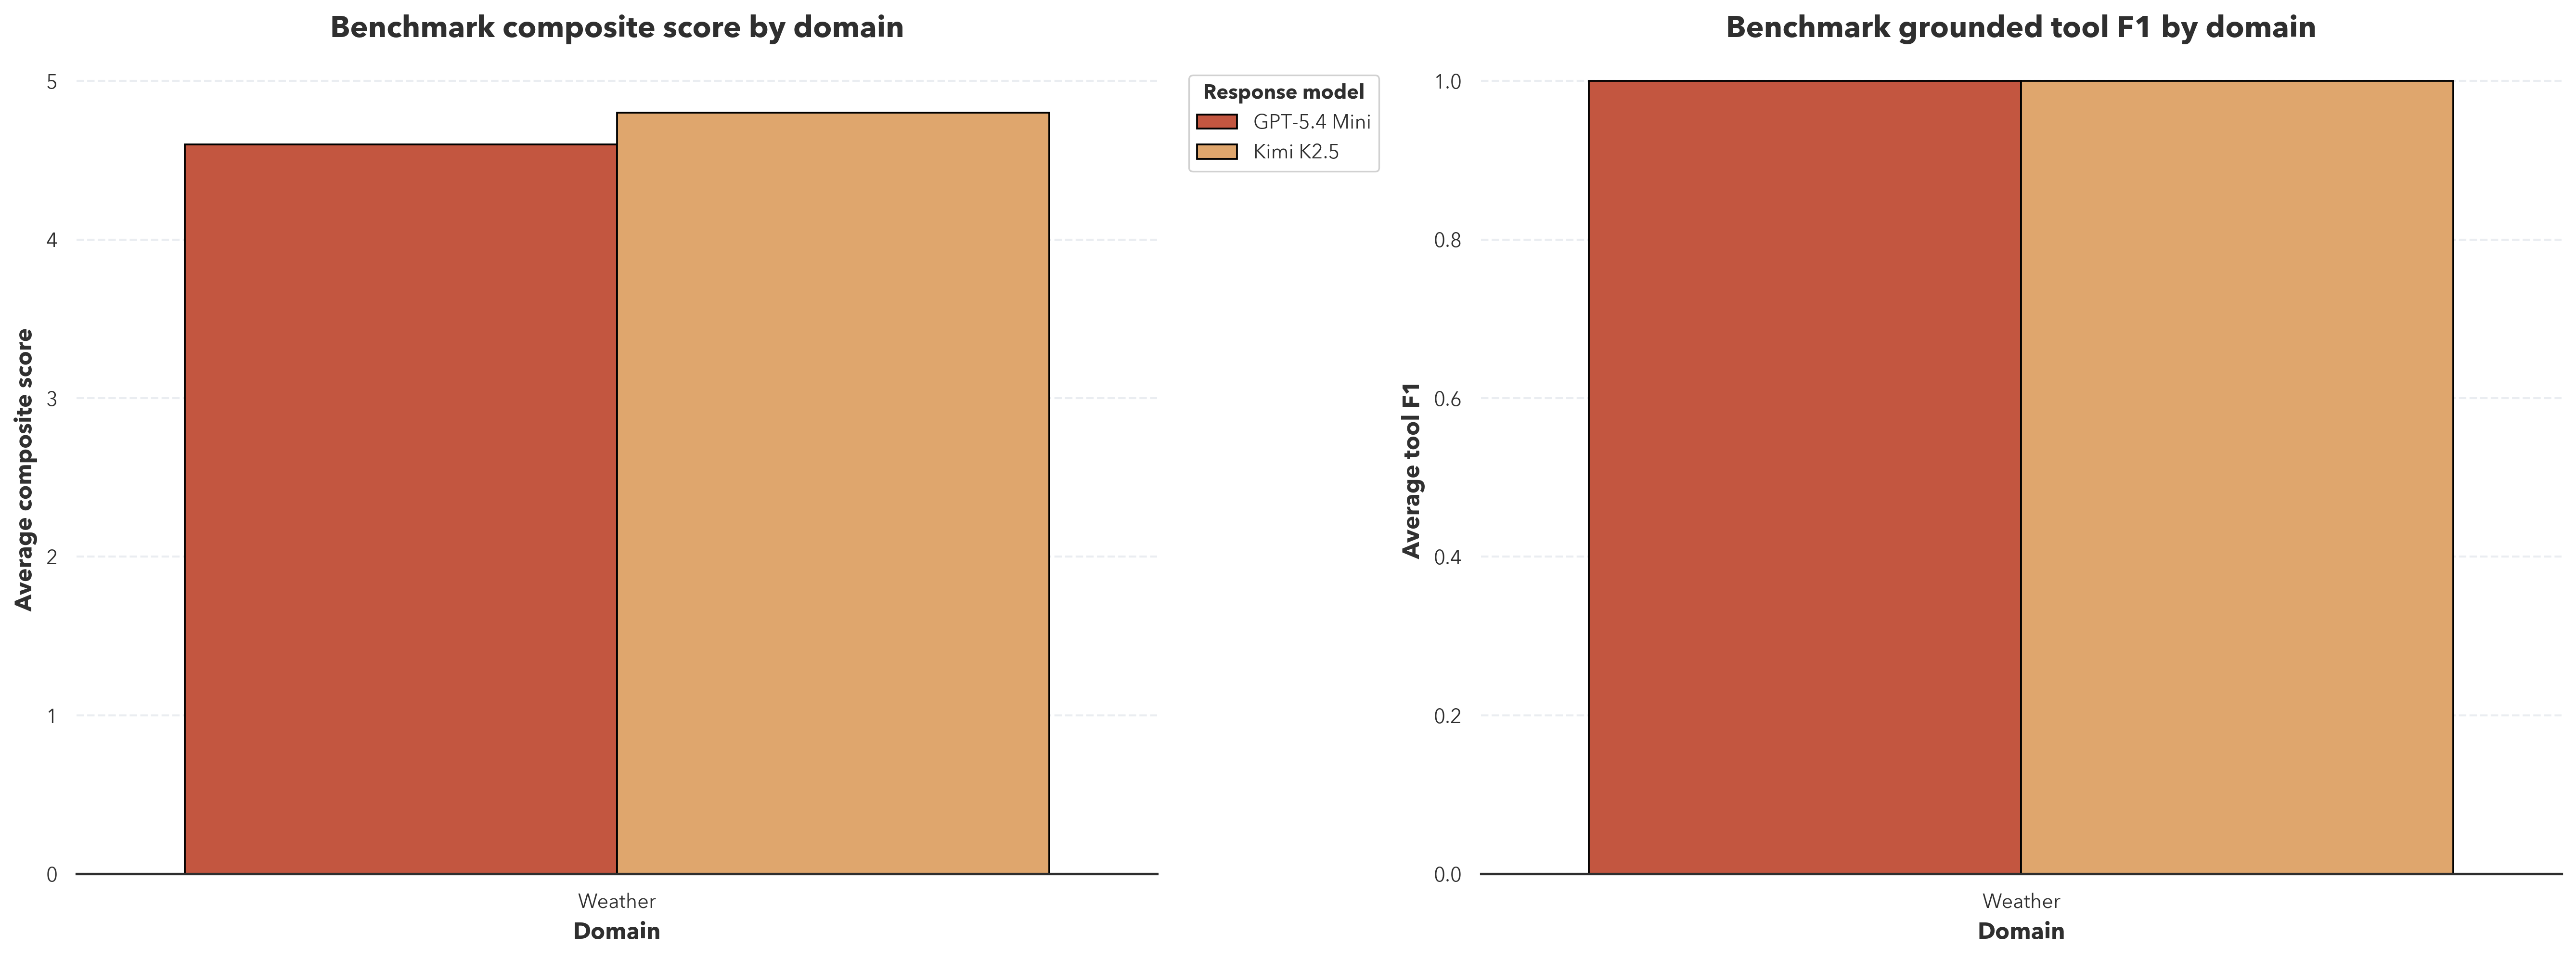

In [9]:
# ==========================================================================
# Benchmark plots: quality and grounding
# ==========================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6.8), dpi=EXPORT_DPI, facecolor="white")

sns.barplot(
    data=benchmark_summary,
    x="domain_label",
    y="avg_composite_score",
    hue="response_model_label",
    order=benchmark_domain_order,
    hue_order=benchmark_model_order,
    palette=benchmark_model_palette,
    edgecolor="black",
    linewidth=0.9,
    ax=axes[0],
)
style_axis(
    axes[0],
    "Benchmark composite score by domain",
    "Domain",
    "Average composite score",
    y_limits=(0, 5.1),
)
style_legend(axes[0], "Response model")

sns.barplot(
    data=benchmark_summary,
    x="domain_label",
    y="avg_tool_f1",
    hue="response_model_label",
    order=benchmark_domain_order,
    hue_order=benchmark_model_order,
    palette=benchmark_model_palette,
    edgecolor="black",
    linewidth=0.9,
    ax=axes[1],
)
style_axis(
    axes[1],
    "Benchmark grounded tool F1 by domain",
    "Domain",
    "Average tool F1",
    y_limits=(0, 1.02),
)
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

plt.tight_layout()
save_figure("benchmark_quality_grounding", fig)
plt.show()

Exported: eval\results\figures\benchmark_operational_profile.svg


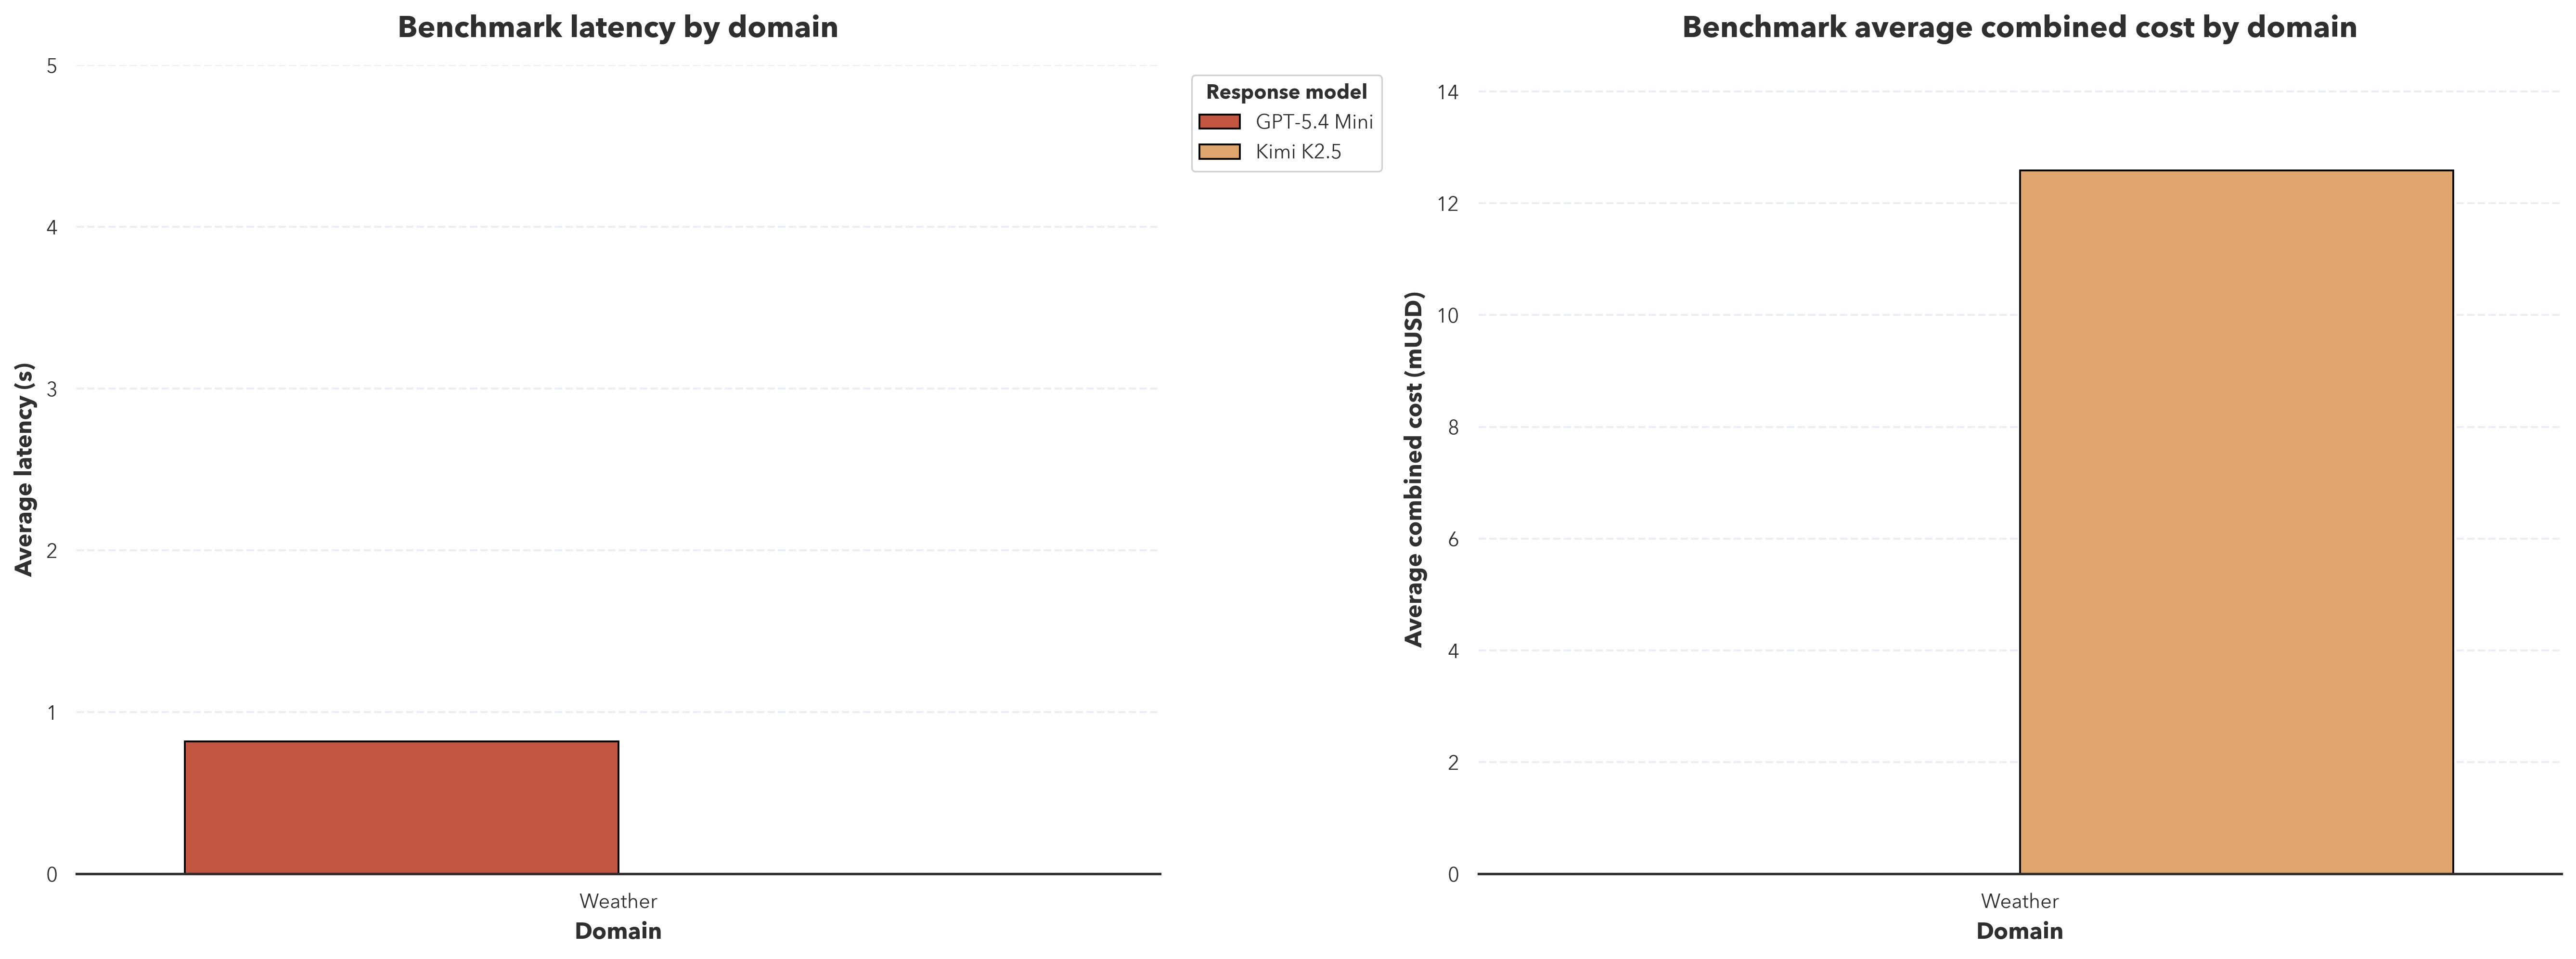

In [10]:
# ==========================================================================
# Benchmark plots: operational profile
# ==========================================================================
benchmark_operational = benchmark_summary.copy()
benchmark_operational["avg_combined_cost_musd"] = benchmark_operational["avg_combined_cost_usd"] * 1000

latency_upper = max(benchmark_operational["avg_latency_s"].max() * 1.15, 5.0)
use_cost_axis = benchmark_operational["avg_combined_cost_usd"].fillna(0).sum() > 0
use_token_axis = benchmark_operational["avg_combined_tokens"].fillna(0).sum() > 0

fig, axes = plt.subplots(1, 2, figsize=(18, 6.8), dpi=EXPORT_DPI, facecolor="white")

sns.barplot(
    data=benchmark_operational,
    x="domain_label",
    y="avg_latency_s",
    hue="response_model_label",
    order=benchmark_domain_order,
    hue_order=benchmark_model_order,
    palette=benchmark_model_palette,
    edgecolor="black",
    linewidth=0.9,
    ax=axes[0],
)
style_axis(
    axes[0],
    "Benchmark latency by domain",
    "Domain",
    "Average latency (s)",
    y_limits=(0, latency_upper),
)
style_legend(axes[0], "Response model")

if use_cost_axis:
    secondary_metric = "avg_combined_cost_musd"
    secondary_title = "Benchmark average combined cost by domain"
    secondary_ylabel = "Average combined cost (mUSD)"
    secondary_upper = max(benchmark_operational[secondary_metric].max() * 1.15, 0.01)
elif use_token_axis:
    secondary_metric = "avg_combined_tokens"
    secondary_title = "Benchmark average combined tokens by domain"
    secondary_ylabel = "Average combined tokens"
    secondary_upper = max(benchmark_operational[secondary_metric].max() * 1.15, 1.0)
else:
    secondary_metric = "heuristics_pass_rate"
    secondary_title = "Benchmark heuristics pass rate by domain"
    secondary_ylabel = "Pass rate"
    secondary_upper = 1.02

sns.barplot(
    data=benchmark_operational,
    x="domain_label",
    y=secondary_metric,
    hue="response_model_label",
    order=benchmark_domain_order,
    hue_order=benchmark_model_order,
    palette=benchmark_model_palette,
    edgecolor="black",
    linewidth=0.9,
    ax=axes[1],
)
style_axis(
    axes[1],
    secondary_title,
    "Domain",
    secondary_ylabel,
    y_limits=(0, secondary_upper),
)
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

plt.tight_layout()
save_figure("benchmark_operational_profile", fig)
plt.show()

## **Ablation analysis**

The ablation compares the same saved query subset across two arms:

- **Zero-shot**: a direct model answer without LISBOA tool grounding.
- **LISBOA**: the full multi-agent pipeline with routing, tool use, QA, and planning when needed.

The emphasis is not on symmetric tool-use scoring. Zero-shot has no tool grounding by design, so the key questions here are:

1. Does LISBOA improve response quality on the same query subset?
2. Where is the improvement strongest by domain?
3. What operational trade-off appears in latency and cost?
4. How should grounded tool metrics be interpreted as LISBOA-only evidence?

In [11]:
# ==========================================================================
# Ablation tables
# ==========================================================================
if not ablation_available:
    ablation_summary = pd.DataFrame()
    ablation_gain = pd.DataFrame()
    ablation_pairwise = pd.DataFrame()
    lisboa_grounding_table = pd.DataFrame()
    display(Markdown("### Ablation artefact status"))
    print("No ablation JSON found under eval/results/ablation/. Run eval/run_ablation.py to populate this section.")
else:
    ablation_df["arm_label"] = ablation_df["arm"].apply(format_arm_label)
    ablation_df["domain_label"] = ablation_df["domain"].apply(format_domain_label)
    ablation_df["response_model_label"] = ablation_df["response_model"].apply(format_model_label)
    ablation_df["evaluation_model_label"] = ablation_df["evaluation_model"].apply(format_model_label)

    ablation_domain_order = [
        label for label in ABLATION_DOMAIN_ORDER if label in ablation_df["domain_label"].unique()
    ]
    ablation_arm_order = ["Zero-shot", "LISBOA"]

    ablation_summary = (
        ablation_df.groupby(["arm_label", "domain_label"], as_index=False)
        .agg(
            queries=("id", "nunique"),
            avg_composite_score=("composite_score", "mean"),
            avg_latency_s=("latency_s", "mean"),
            heuristics_pass_rate=("heuristics_pass", "mean"),
            avg_combined_tokens=("combined_total_tokens", "mean"),
            avg_combined_cost_usd=("combined_total_cost_usd", "mean"),
        )
    )
    ablation_summary["arm_label"] = pd.Categorical(
        ablation_summary["arm_label"],
        categories=ablation_arm_order,
        ordered=True,
    )
    ablation_summary["domain_label"] = pd.Categorical(
        ablation_summary["domain_label"],
        categories=ablation_domain_order,
        ordered=True,
    )
    ablation_summary = ablation_summary.sort_values(["arm_label", "domain_label"])
    ablation_summary["avg_combined_cost_musd"] = ablation_summary["avg_combined_cost_usd"] * 1000

    ablation_gain = (
        ablation_summary.pivot_table(
            index="domain_label",
            columns="arm_label",
            values="avg_composite_score",
            aggfunc="first",
            observed=False,
        )
        .reset_index()
    )
    ablation_gain.columns.name = None
    ablation_gain["score_lift"] = ablation_gain.get("LISBOA", 0) - ablation_gain.get("Zero-shot", 0)
    ablation_gain["domain_label"] = pd.Categorical(
        ablation_gain["domain_label"],
        categories=ablation_domain_order,
        ordered=True,
    )
    ablation_gain = ablation_gain.sort_values("domain_label")

    ablation_pairwise = (
        ablation_df.pivot_table(
            index=["id", "domain_label", "query"],
            columns="arm_label",
            values="composite_score",
            aggfunc="first",
            observed=False,
        )
        .reset_index()
    )
    ablation_pairwise.columns.name = None
    ablation_pairwise["lisboa_minus_zero_shot"] = (
        ablation_pairwise.get("LISBOA", np.nan) - ablation_pairwise.get("Zero-shot", np.nan)
    )
    ablation_pairwise["winner"] = np.where(
        ablation_pairwise["lisboa_minus_zero_shot"] > 0,
        "LISBOA",
        np.where(ablation_pairwise["lisboa_minus_zero_shot"] < 0, "Zero-shot", "Tie"),
    )

    meaningful_grounding_domains = set(
        corpus_df.loc[
            corpus_df["id"].isin(ablation_df["id"]) & (corpus_df["expected_tool_count"] > 0),
            "domain_label",
        ]
    )
    lisboa_grounding_table = (
        ablation_df[
            (ablation_df["arm_label"] == "LISBOA")
            & (ablation_df["domain_label"].isin(meaningful_grounding_domains))
        ]
        .groupby("domain_label", as_index=False)
        .agg(
            avg_tool_precision=("tool_precision", "mean"),
            avg_tool_recall=("tool_recall", "mean"),
            avg_tool_f1=("tool_f1", "mean"),
        )
        .rename(
            columns={
                "domain_label": "Domain",
                "avg_tool_precision": "LISBOA avg tool precision",
                "avg_tool_recall": "LISBOA avg tool recall",
                "avg_tool_f1": "LISBOA avg tool F1",
            }
        )
    )

    ablation_quality_table = ablation_summary.rename(
        columns={
            "arm_label": "Arm",
            "domain_label": "Domain",
            "queries": "Queries",
            "avg_composite_score": "Avg composite score",
            "heuristics_pass_rate": "Heuristics pass rate",
        }
    )[["Arm", "Domain", "Queries", "Avg composite score", "Heuristics pass rate"]]

    ablation_operational_table = ablation_summary.rename(
        columns={
            "arm_label": "Arm",
            "domain_label": "Domain",
            "avg_latency_s": "Avg latency (s)",
            "avg_combined_tokens": "Avg combined tokens",
            "avg_combined_cost_usd": "Avg combined cost (USD)",
        }
    )[["Arm", "Domain", "Avg latency (s)", "Avg combined tokens", "Avg combined cost (USD)"]]

    ablation_gain_table = ablation_gain.rename(
        columns={
            "domain_label": "Domain",
            "Zero-shot": "Zero-shot avg score",
            "LISBOA": "LISBOA avg score",
            "score_lift": "Score lift (LISBOA - Zero-shot)",
        }
    )

    ablation_pairwise_view = ablation_pairwise.rename(
        columns={
            "id": "Query ID",
            "domain_label": "Domain",
            "query": "Query",
            "Zero-shot": "Zero-shot score",
            "LISBOA": "LISBOA score",
            "lisboa_minus_zero_shot": "Score lift",
            "winner": "Winner",
        }
    )

    display(Markdown("### Ablation quality summary"))
    display(ablation_quality_table.round(6))

    display(Markdown("### Ablation operational summary"))
    display(ablation_operational_table.round(6))

    display(Markdown("### Domain-level quality lift"))
    display(ablation_gain_table.round(6))

    display(Markdown("### LISBOA-only grounded tool metrics"))
    display(lisboa_grounding_table.round(6))

    display(Markdown("### Per-query score comparison"))
    display(ablation_pairwise_view.round(6))

### Ablation artefact status

No ablation JSON found under eval/results/ablation/. Run eval/run_ablation.py to populate this section.


In [12]:
# ==========================================================================
# Ablation plots: quality comparison and score lift
# ==========================================================================
if ablation_summary.empty or ablation_gain.empty:
    print("Skipping ablation quality plots because no ablation artefact is available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6.8), dpi=EXPORT_DPI, facecolor="white")

    sns.barplot(
        data=ablation_summary,
        x="domain_label",
        y="avg_composite_score",
        hue="arm_label",
        order=ablation_domain_order,
        hue_order=ablation_arm_order,
        palette=ARM_PALETTE,
        edgecolor="black",
        linewidth=0.9,
        ax=axes[0],
    )
    style_axis(
        axes[0],
        "Ablation composite score by domain",
        "Domain",
        "Average composite score",
        rotate_xticks=18,
        y_limits=(0, 5.1),
    )
    style_legend(axes[0], "Arm")

    gain_palette = [PRIMARY_RED if value >= 0 else NEUTRAL_GREY for value in ablation_gain["score_lift"].fillna(0)]
    axes[1].bar(
        ablation_gain["domain_label"].astype(str),
        ablation_gain["score_lift"],
        color=gain_palette,
        edgecolor="black",
        linewidth=0.9,
    )
    axes[1].axhline(0, color=DARK_GREY, linewidth=1.1, linestyle="--")
    style_axis(
        axes[1],
        "Ablation score lift by domain",
        "Domain",
        "LISBOA - Zero-shot",
        rotate_xticks=18,
    )

    plt.tight_layout()
    save_figure("ablation_quality_lift", fig)
    plt.show()

Skipping ablation quality plots because no ablation artefact is available.


In [13]:
# ==========================================================================
# Ablation plots: trade-offs and operational profile
# ==========================================================================
if ablation_summary.empty:
    print("Skipping ablation trade-off plots because no ablation artefact is available.")
else:
    latency_upper = max(ablation_summary["avg_latency_s"].max() * 1.15, 5.0)
    use_cost_axis = ablation_summary["avg_combined_cost_usd"].fillna(0).sum() > 0
    use_token_axis = ablation_summary["avg_combined_tokens"].fillna(0).sum() > 0

    if use_cost_axis:
        secondary_metric = "avg_combined_cost_musd"
        secondary_title = "Ablation average combined cost by domain"
        secondary_ylabel = "Average combined cost (mUSD)"
        secondary_upper = max(ablation_summary[secondary_metric].max() * 1.15, 0.01)
    elif use_token_axis:
        secondary_metric = "avg_combined_tokens"
        secondary_title = "Ablation average combined tokens by domain"
        secondary_ylabel = "Average combined tokens"
        secondary_upper = max(ablation_summary[secondary_metric].max() * 1.15, 1.0)
    else:
        secondary_metric = "heuristics_pass_rate"
        secondary_title = "Ablation heuristics pass rate by domain"
        secondary_ylabel = "Pass rate"
        secondary_upper = 1.02

    fig, axes = plt.subplots(1, 2, figsize=(18, 6.8), dpi=EXPORT_DPI, facecolor="white")

    sns.barplot(
        data=ablation_summary,
        x="domain_label",
        y="avg_latency_s",
        hue="arm_label",
        order=ablation_domain_order,
        hue_order=ablation_arm_order,
        palette=ARM_PALETTE,
        edgecolor="black",
        linewidth=0.9,
        ax=axes[0],
    )
    style_axis(
        axes[0],
        "Ablation latency by domain",
        "Domain",
        "Average latency (s)",
        rotate_xticks=18,
        y_limits=(0, latency_upper),
    )
    style_legend(axes[0], "Arm")

    sns.barplot(
        data=ablation_summary,
        x="domain_label",
        y=secondary_metric,
        hue="arm_label",
        order=ablation_domain_order,
        hue_order=ablation_arm_order,
        palette=ARM_PALETTE,
        edgecolor="black",
        linewidth=0.9,
        ax=axes[1],
    )
    style_axis(
        axes[1],
        secondary_title,
        "Domain",
        secondary_ylabel,
        rotate_xticks=18,
        y_limits=(0, secondary_upper),
    )
    if axes[1].legend_ is not None:
        axes[1].legend_.remove()

    plt.tight_layout()
    save_figure("ablation_tradeoffs", fig)
    plt.show()

Skipping ablation trade-off plots because no ablation artefact is available.


In [14]:
# ==========================================================================
# Coverage, provider consistency, and optional calibration
# ==========================================================================
display(Markdown("## Coverage and provider consistency"))

if coverage_payload is not None:
    coverage_overview = pd.DataFrame(
        [
            {
                "Artefact": str(coverage_path.relative_to(PROJECT_ROOT)),
                "Prompts": coverage_summary_payload.get("total_prompts", len(coverage_df)),
                "Successful prompts": coverage_summary_payload.get("successful_prompts", np.nan),
                "Average tool F1": coverage_summary_payload.get("avg_tool_f1", np.nan),
                "Full registry covered": coverage_summary_payload.get("full_registry_coverage_met", False),
                "Missing tools": len(coverage_summary_payload.get("missing_tools", [])),
            }
        ]
    )
    display(Markdown("### Strict live coverage snapshot"))
    display(coverage_overview.round(6))

    if not coverage_df.empty:
        coverage_df["domain_label"] = coverage_df["domain"].apply(format_domain_label)
        coverage_domain_summary = (
            coverage_df.groupby("domain_label", as_index=False)
            .agg(
                prompts=("id", "count"),
                pass_rate=("coverage_pass", "mean"),
                avg_tool_f1=("tool_metrics", lambda values: np.mean([(value or {}).get("tool_f1", np.nan) for value in values])),
                avg_latency_s=("latency_s", "mean"),
            )
            .rename(
                columns={
                    "domain_label": "Domain",
                    "prompts": "Prompts",
                    "pass_rate": "Coverage pass rate",
                    "avg_tool_f1": "Avg tool F1",
                    "avg_latency_s": "Avg latency (s)",
                }
            )
        )
        display(Markdown("### Coverage by domain"))
        display(coverage_domain_summary.round(6))
else:
    print("No coverage JSON found. Run the strict live coverage suite when you need this section.")

if consistency_payload is not None:
    consistency_overview = pd.DataFrame(
        [
            {
                "Artefact": str(consistency_path.relative_to(PROJECT_ROOT)),
                "Providers compared": ", ".join(consistency_payload.get("providers", [])),
                "Prompts": consistency_summary_payload.get("total_prompts", np.nan),
                "Completed comparisons": consistency_summary_payload.get("completed_comparisons", np.nan),
                "Consistency rate": consistency_summary_payload.get("consistency_rate", np.nan),
            }
        ]
    )
    display(Markdown("### Provider consistency snapshot"))
    display(consistency_overview.round(6))

    per_provider = consistency_summary_payload.get("per_provider", {}) or {}
    if per_provider:
        consistency_provider_summary = (
            pd.DataFrame.from_dict(per_provider, orient="index")
            .reset_index()
            .rename(
                columns={
                    "index": "Provider",
                    "count": "Comparisons",
                    "avg_latency_s": "Avg latency (s)",
                    "overall_pass_rate": "Heuristics pass rate",
                }
            )
        )
        display(Markdown("### Provider-level comparison"))
        display(consistency_provider_summary.round(6))

    if not consistency_df.empty:
        consistency_df["category_label"] = consistency_df["category"].apply(format_domain_label)
        consistency_view = consistency_df.rename(
            columns={
                "id": "Query ID",
                "category_label": "Category",
                "provider": "Provider",
                "model_name": "Model",
                "latency_s": "Latency (s)",
                "overall_pass": "Heuristics pass",
                "consistent": "Consistent",
            }
        )
        display(Markdown("### Query-level provider consistency view"))
        display(consistency_view[["Query ID", "Category", "Provider", "Model", "Latency (s)", "Heuristics pass", "Consistent"]].round(6))
else:
    print("No provider consistency JSON found. Add this section only after running the consistency script.")

if calibration_payload is not None:
    calibration_summary = pd.json_normalize(calibration_payload.get("summary", {}).get("per_dimension", {}), sep=".")
    display(Markdown("### Optional calibration snapshot"))
    display(calibration_summary.T)
else:
    print("No calibration JSON found. Human-vs-judge calibration remains optional until scores are available.")

## Coverage and provider consistency

No coverage JSON found. Run the strict live coverage suite when you need this section.
No provider consistency JSON found. Add this section only after running the consistency script.
No calibration JSON found. Human-vs-judge calibration remains optional until scores are available.


In [15]:
# ==========================================================================
# Optional flat-table export policy
# ==========================================================================
if EXPORT_FLAT_TABLES:
    benchmark_flat_path = EVAL_RESULTS_DIR / "benchmark" / "benchmark_flat_latest.csv"
    benchmark_summary_path = EVAL_RESULTS_DIR / "benchmark" / "benchmark_summary_latest.csv"
    ablation_flat_path = EVAL_RESULTS_DIR / "ablation" / "ablation_flat_latest.csv"
    ablation_summary_path = EVAL_RESULTS_DIR / "ablation" / "ablation_summary_latest.csv"

    benchmark_df.to_csv(benchmark_flat_path, index=False)
    benchmark_summary.to_csv(benchmark_summary_path, index=False)
    ablation_df.to_csv(ablation_flat_path, index=False)
    ablation_summary.to_csv(ablation_summary_path, index=False)

    print("Exported flat tables:")
    print(f" - {benchmark_flat_path.relative_to(PROJECT_ROOT)}")
    print(f" - {benchmark_summary_path.relative_to(PROJECT_ROOT)}")
    print(f" - {ablation_flat_path.relative_to(PROJECT_ROOT)}")
    print(f" - {ablation_summary_path.relative_to(PROJECT_ROOT)}")
else:
    print("Flat CSV export is disabled by default in this notebook.")
    print("Set EXPORT_FLAT_TABLES = True in the setup cell if you need appendix-ready CSV snapshots.")

print("Main figure export policy:")
print(f" - Automatic figure export enabled: {EXPORT_MAIN_FIGURES}")
print(f" - Exported figure names: {', '.join(sorted(MAIN_FIGURE_EXPORTS))}")

Flat CSV export is disabled by default in this notebook.
Set EXPORT_FLAT_TABLES = True in the setup cell if you need appendix-ready CSV snapshots.
Main figure export policy:
 - Automatic figure export enabled: True
 - Exported figure names: ablation_quality_lift, ablation_tradeoffs, benchmark_operational_profile, benchmark_quality_grounding


## **Notes for thesis writing**

- This notebook separates the **shared corpus definition** from the smaller persisted subsets used by benchmark, ablation, coverage, and provider-consistency artefacts.
- The main benchmark figures compare isolated worker-agent behaviour, not the full LISBOA orchestration pipeline.
- The ablation figures focus on **quality lift** and **operational trade-offs**, not on a symmetric tool-use comparison between zero-shot and LISBOA.
- Coverage and provider consistency are summarised compactly because they support the evaluation narrative but should not dominate the main thesis figures.
- Automatic export is restricted to the main SVG figures only. Flat CSV snapshots remain optional and can be enabled explicitly when needed for appendix work.
- Model labels shown in the notebook are cleaned for readability, but the underlying metadata is always read from the saved JSON artefacts.
- The demo corpus should be run with custom output prefixes such as `ablation_demo` or `benchmark_demo`, so it is persisted for presentation purposes without replacing the main latest artefacts used by this notebook.